<a href="https://colab.research.google.com/github/greeshmakrishnan00/Machine-Learning/blob/main/Fast_Food_Classification_ML_(Cross_Validation).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load and Inspect the Data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/fast_food_classification_dataset.csv')
df

,id,calories,fat,protein,carbs,sodium,sugar,food_type,restaurant,meal_time,rating,spice_level,label
0,1,1176,50.778449,0.228903,69.862515,1121,48.452796,Fries,BurgerKing,Lunch,2.692600,Medium,Healthy
1,2,910,32.858087,42.085096,9.882800,1281,29.611529,Sandwich,KFC,Lunch,1.212646,High,Moderate
2,3,1180,36.148174,2.978126,112.422041,829,88.431292,Drink,BurgerKing,Lunch,4.013493,Medium,Healthy
3,4,1145,56.249476,20.517021,110.733740,145,39.856243,Sandwich,KFC,Breakfast,3.127551,NaN,Moderate
4,5,1094,33.549089,5.550925,20.288597,751,0.560775,Burger,Dominos,Breakfast,NaN,High,Unhealthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39996,1012,37.975805,39.605937,26.915581,1498,73.162282,Sandwich,McD,Snack,1.822923,Medium,Healthy
39996,39997,769,42.956273,36.213474,44.921037,1847,88.801045,Sandwich,Dominos,Lunch,NaN,NaN,Moderate
39997,39998,1005,30.224685,37.186665,119.488666,977,29.588347,Burger,Dominos,Lunch,3.681435,NaN,Unhealthy
39998,39999,275,37.137679,28.305692,103.508364,451,85.477879,Pizza,Dominos,Snack,2.622652,High,Unhealthy


# Understand the Data Types and Summary

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   calories     40000 non-null  int64  
 2   fat          40000 non-null  float64
 3   protein      40000 non-null  float64
 4   carbs        40000 non-null  float64
 5   sodium       40000 non-null  int64  
 6   sugar        40000 non-null  float64
 7   food_type    40000 non-null  object 
 8   restaurant   40000 non-null  object 
 9   meal_time    40000 non-null  object 
 10  rating       29923 non-null  float64
 11  spice_level  30060 non-null  object 
 12  label        40000 non-null  object 
dtypes: float64(5), int64(3), object(5)
memory usage: 4.0+ MB


In [ ]:
df.isnull().sum()

,0
id,0
calories,0
fat,0
protein,0
carbs,0
sodium,0
sugar,0
food_type,0
restaurant,0
meal_time,0


(array([13224.,     0.,     0.,     0.,     0., 13331.,     0.,     0.,
            0., 13445.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

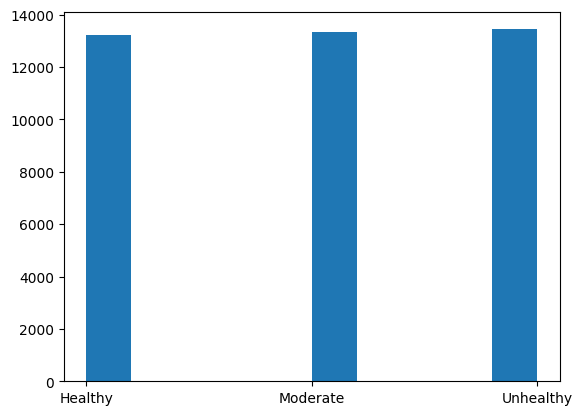

In [ ]:
plt.hist(df["label"])

In [ ]:
df["rating"].fillna(df["rating"].median(),inplace=True)

/tmp/ipykernel_19174/1458218175.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["rating"].fillna(df["rating"].median(),inplace=True)


In [ ]:
df["spice_level"].fillna(df["spice_level"].mode()[0],inplace=True)

/tmp/ipykernel_19174/2398133558.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["spice_level"].fillna(df["spice_level"].mode()[0],inplace=True)


In [ ]:
df.isnull().sum()

,0
id,0
calories,0
fat,0
protein,0
carbs,0
sodium,0
sugar,0
food_type,0
restaurant,0
meal_time,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Visualization

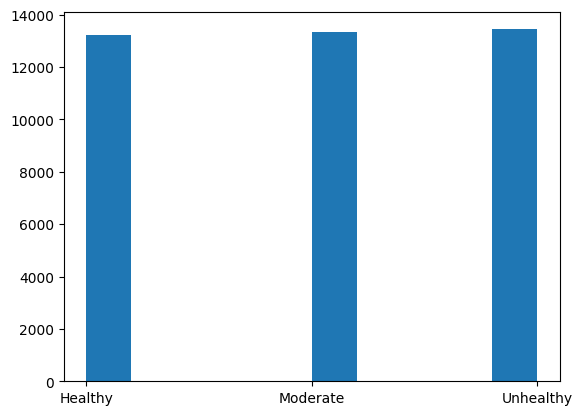

In [ ]:
plt.hist(df["label"])
plt.show()

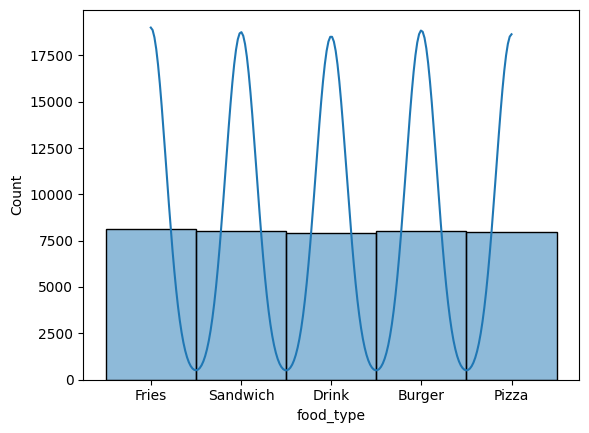

In [ ]:
sns.histplot(df["food_type"],kde=True)
plt.show()

#Correlation Analysis in EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   calories     40000 non-null  int64  
 2   fat          40000 non-null  float64
 3   protein      40000 non-null  float64
 4   carbs        40000 non-null  float64
 5   sodium       40000 non-null  int64  
 6   sugar        40000 non-null  float64
 7   food_type    40000 non-null  object 
 8   restaurant   40000 non-null  object 
 9   meal_time    40000 non-null  object 
 10  rating       40000 non-null  float64
 11  spice_level  40000 non-null  object 
 12  label        40000 non-null  object 
dtypes: float64(5), int64(3), object(5)
memory usage: 4.0+ MB


In [ ]:
print(df["food_type"].unique())

['Fries' 'Sandwich' 'Drink' 'Burger' 'Pizza']


In [ ]:
print(df["restaurant"].unique())

['BurgerKing' 'KFC' 'Dominos' 'Subway' 'McD']


In [ ]:
print(df["meal_time"].unique())

['Lunch' 'Breakfast' 'Snack' 'Dinner']


In [ ]:
print(df["spice_level"].unique())

['Medium' 'High' 'Low']


In [ ]:
print(df["label"].unique())

['Healthy' 'Moderate' 'Unhealthy']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['food_type']=le.fit_transform(df['food_type'])
df['restaurant']=le.fit_transform(df['restaurant'])
df['meal_time']=le.fit_transform(df['meal_time'])
df['spice_level']=le.fit_transform(df['spice_level'])
df['label']=le.fit_transform(df['label'])

In [ ]:
df.shape

(40000, 13)

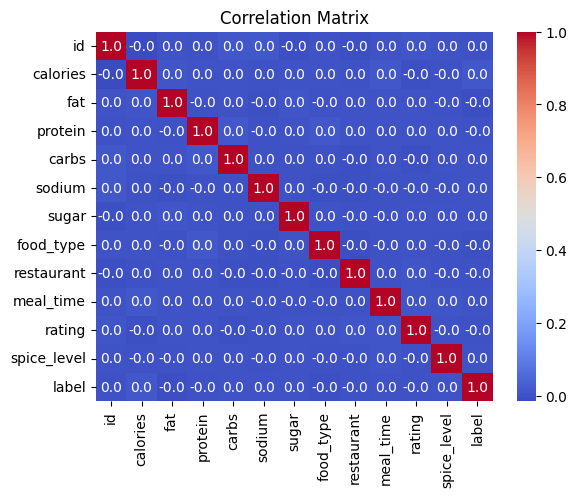

In [ ]:
core_matrix=df.corr()
sns.heatmap(core_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

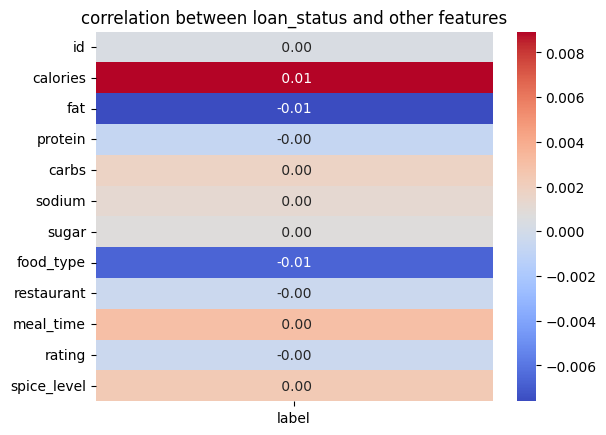

In [ ]:
status_corr=df.corr()["label"]
status_corr=status_corr.drop("label")
sns.heatmap(status_corr.to_frame(), annot=True,fmt=' .2f',cmap='coolwarm',cbar=True, annot_kws={'size':10})
plt.title('correlation between loan_status and other features')
plt.show()

In [ ]:
df.columns

Index(['id', 'calories', 'fat', 'protein', 'carbs', 'sodium', 'sugar',
       'food_type', 'restaurant', 'meal_time', 'rating', 'spice_level',
       'label'],
      dtype='object')

In [ ]:
df.drop(['id','rating','protein'],axis=1,inplace=True)

In [ ]:
df.shape

(40000, 10)

# Outlier cheking and removing

<Axes: >

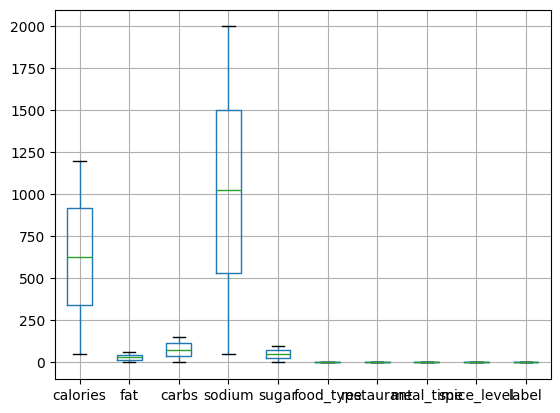

In [ ]:
df.boxplot()

In [ ]:
df.shape

(40000, 10)

In [ ]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
       continue
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR =Q3-Q1
    lower_bound = Q1 -1.5 *IQR
    upper_bound = Q3 +1.5 *IQR
    df=df[(df[col]>= lower_bound)&(df[col]<=upper_bound)]
  return df

df_cleaned= remove_outliers_iqr(df,exclude_column='label')
df=df_cleaned

In [ ]:
df.shape

(40000, 10)

# Data Scaling

In [ ]:
df.columns

Index(['calories', 'fat', 'carbs', 'sodium', 'sugar', 'food_type',
       'restaurant', 'meal_time', 'spice_level', 'label'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features =['calories', 'fat', 'carbs', 'sodium', 'sugar', 'food_type',
       'restaurant', 'meal_time', 'spice_level']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[['calories', 'fat', 'carbs', 'sodium', 'sugar', 'food_type',
       'restaurant', 'meal_time', 'spice_level']]
y=df["label"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.34


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# DECISION TREE

In [ ]:
from sklearn.tree import DecisionTreeClassifier

x=df[['calories', 'fat', 'carbs', 'sodium', 'sugar', 'food_type',
       'restaurant', 'meal_time', 'spice_level']]
y=df["label"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=DecisionTreeClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.33


# SVM - SVC

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Features and target
x = df[['calories', 'fat', 'carbs', 'sodium', 'sugar',
        'food_type', 'restaurant', 'meal_time', 'spice_level']]
y = df["label"]

# Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

# Pipeline: Scaling + Linear SVC
model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

# Train
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Pipeline Linear SVC Accuracy: {accuracy:.2f}")

Pipeline Linear SVC Accuracy: 0.34


# RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier

x=df[['calories', 'fat', 'carbs', 'sodium', 'sugar', 'food_type',
       'restaurant', 'meal_time', 'spice_level']]
y=df["label"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=RandomForestClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.34


# ADABOOST

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

x=df[['calories', 'fat', 'carbs', 'sodium', 'sugar', 'food_type',
       'restaurant', 'meal_time', 'spice_level']]
y=df["label"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=AdaBoostClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.34


# XGBOOST

In [ ]:
from  xgboost import XGBClassifier

x=df[['calories', 'fat', 'carbs', 'sodium', 'sugar', 'food_type',
       'restaurant', 'meal_time', 'spice_level']]
y=df["label"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=XGBClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.33


# XGBClassifier Hyperparameters

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

x = df[['calories', 'fat', 'carbs', 'sodium', 'sugar',
        'food_type', 'restaurant', 'meal_time', 'spice_level']]
y = df["label"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=2,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Tuned model accuracy: {accuracy:.2f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:29:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tuned model accuracy: 0.34
